# Homework Submission - Stage 10a: Linear Regression

This completion follows the official starter: fit a chronological baseline, evaluate out-of-sample metrics, diagnose residual assumptions, compare a transformed-feature specification, and state exactly what the model can and cannot support.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
np.random.seed(7)
ROOT = Path.cwd()
FIGURES = ROOT / 'reports' / 'images'
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Generate the starter's finance-flavored dataset

In [2]:
n = 200
dates = pd.bdate_range(start='2024-02-01', periods=n)
mkt_excess = np.random.normal(0, 0.011, size=n)
size = np.random.normal(0, 0.008, size=n)
value = np.random.normal(0, 0.009, size=n)
momentum = np.random.normal(0, 0.006, size=n)
noise_scale = 0.0035 + 0.5 * np.abs(mkt_excess)
eps = np.random.normal(0, noise_scale)
asset_excess = (
    0.0001 + 0.9 * mkt_excess + 0.25 * size - 0.15 * value
    + 0.35 * momentum + 3.5 * momentum**2 + eps
)
df = pd.DataFrame({
    'date': dates,
    'mkt_excess': mkt_excess,
    'size': size,
    'value': value,
    'momentum': momentum,
    'asset_excess': asset_excess,
})
display(df.head())
print('Shape:', df.shape, '| Missing:', int(df.isna().sum().sum()))

,date,mkt_excess,size,value,momentum,asset_excess
0,2024-02-01,0.018596,-0.013467,-0.000540,0.000141,0.014832
1,2024-02-02,-0.005125,0.008120,0.007089,-0.006840,-0.008599
2,2024-02-05,0.000361,-0.011532,-0.012885,-0.011216,-0.009577
3,2024-02-06,0.004483,-0.010749,0.003905,-0.010685,0.000033
4,2024-02-07,-0.008678,-0.002893,0.001250,0.002779,-0.005750


Shape: (200, 6) | Missing: 0


## 2. Baseline fit with a chronological 80/20 split

A chronological split matches the data's time ordering and prevents later observations from entering training. R-squared measures variance explained relative to the test mean; RMSE is in daily excess-return units.

In [3]:
features = ['mkt_excess', 'size', 'value', 'momentum']
target = 'asset_excess'
cut = int(len(df) * 0.80)
train, test = df.iloc[:cut].copy(), df.iloc[cut:].copy()

baseline = LinearRegression().fit(train[features], train[target])
train_prediction = baseline.predict(train[features])
test_prediction = baseline.predict(test[features])

def model_metrics(y_true, prediction):
    return {
        'r2': r2_score(y_true, prediction),
        'rmse': mean_squared_error(y_true, prediction) ** 0.5,
    }

metric_table = pd.DataFrame({
    'train': model_metrics(train[target], train_prediction),
    'test': model_metrics(test[target], test_prediction),
}).T
coefficient_table = pd.Series(baseline.coef_, index=features, name='coefficient').to_frame()
display(metric_table)
display(coefficient_table)

,r2,rmse
train,0.554751,0.007742
test,0.367706,0.008470


,coefficient
mkt_excess,0.778493
size,0.231084
value,-0.209886
momentum,0.181456


## 3. Residual diagnostics

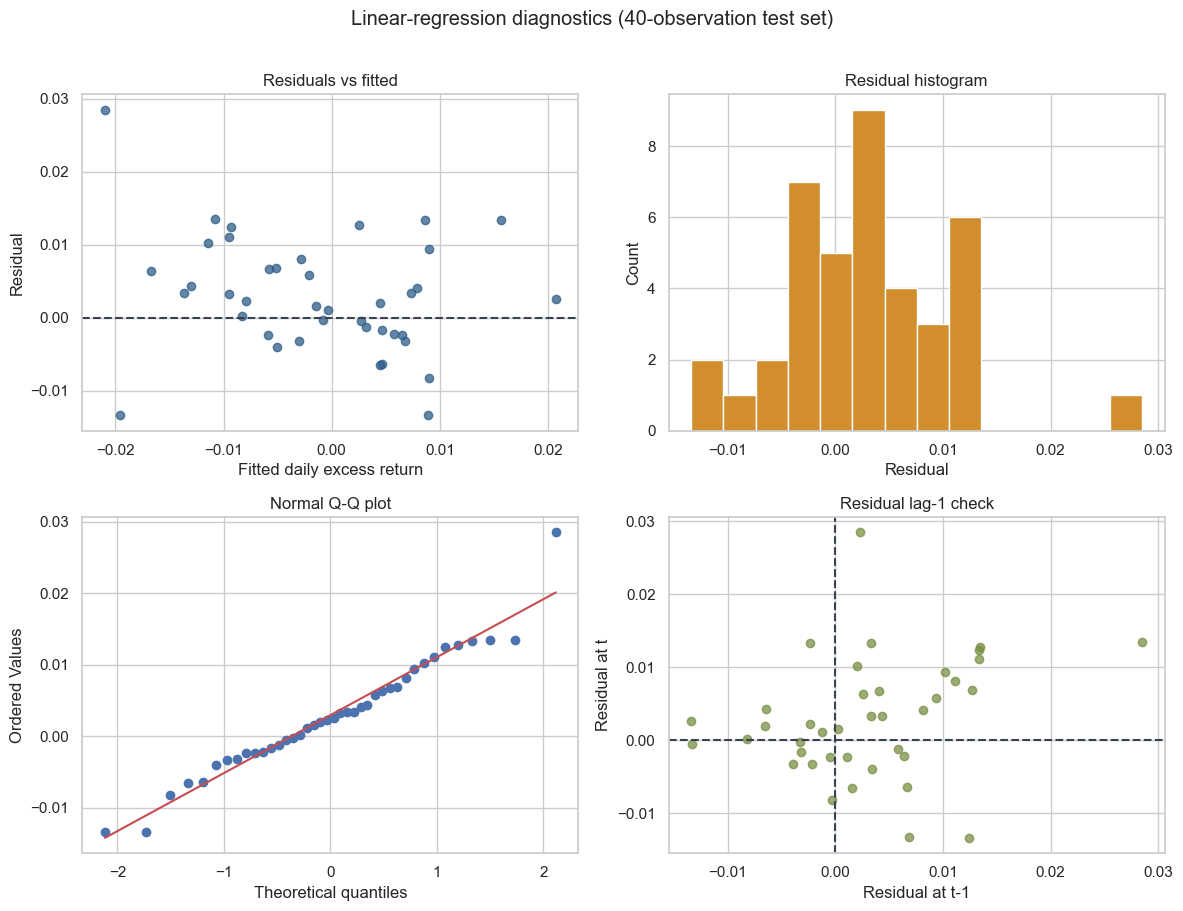

,diagnostic
shapiro_pvalue,0.235451
spearman_abs_resid_vs_abs_market,0.583302
lag1_residual_correlation,0.259985


In [4]:
residuals = test[target].to_numpy() - test_prediction
fitted = test_prediction
lag_residuals = residuals[:-1]
lead_residuals = residuals[1:]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].scatter(fitted, residuals, alpha=0.75, color='#2F5D8A')
axes[0, 0].axhline(0, linestyle='--', color='#374151')
axes[0, 0].set(title='Residuals vs fitted', xlabel='Fitted daily excess return', ylabel='Residual')

axes[0, 1].hist(residuals, bins=14, color='#D28E2D', edgecolor='white')
axes[0, 1].set(title='Residual histogram', xlabel='Residual', ylabel='Count')

st.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q plot')

axes[1, 1].scatter(lag_residuals, lead_residuals, alpha=0.75, color='#7A8F45')
axes[1, 1].axhline(0, linestyle='--', color='#374151')
axes[1, 1].axvline(0, linestyle='--', color='#374151')
axes[1, 1].set(title='Residual lag-1 check', xlabel='Residual at t-1', ylabel='Residual at t')

fig.suptitle('Linear-regression diagnostics (40-observation test set)', y=1.01)
fig.tight_layout()
diagnostic_path = FIGURES / 'linear_regression_diagnostics.png'
fig.savefig(diagnostic_path, dpi=180, bbox_inches='tight')
plt.show()

diagnostics = pd.Series({
    'shapiro_pvalue': st.shapiro(residuals).pvalue,
    'spearman_abs_resid_vs_abs_market': st.spearmanr(
        np.abs(residuals), np.abs(test['mkt_excess'])
    ).statistic,
    'lag1_residual_correlation': np.corrcoef(lag_residuals, lead_residuals)[0, 1],
}, name='diagnostic')
display(diagnostics.to_frame())

**Assumption read:** residuals remain centered around zero, but their magnitude increases with absolute market movement, which is consistent with the deliberately heteroscedastic noise. The Q-Q/histogram do not show an overwhelming normality failure in only 40 test rows, so the Shapiro result should not be overinterpreted. Lag-1 correlation is moderate in this one seeded sample; it is a warning to check time dependence on more data, not proof of a stable autocorrelation process.

## 4. Add a quadratic momentum feature

In [5]:
df['momentum_sq'] = df['momentum'] ** 2
expanded_features = features + ['momentum_sq']
train2, test2 = df.iloc[:cut].copy(), df.iloc[cut:].copy()
transformed = LinearRegression().fit(train2[expanded_features], train2[target])
transformed_prediction = transformed.predict(test2[expanded_features])

comparison = pd.DataFrame({
    'baseline': model_metrics(test[target], test_prediction),
    'with_momentum_sq': model_metrics(test2[target], transformed_prediction),
}).T
display(comparison)
print('momentum_sq coefficient:', transformed.coef_[-1])

,r2,rmse
baseline,0.367706,0.008470
with_momentum_sq,0.368093,0.008467


momentum_sq coefficient: 20.23170025481943


Adding `momentum_sq` is still linear regression because the outcome is a linear combination of coefficients; only the input basis changed. In the executed test results, the quadratic term changes R-squared and RMSE only marginally. Its large-looking coefficient is paired with a very small squared input scale and is not by itself evidence of economic importance.

## 5. Trust conclusion

- **Linearity/specification:** the baseline captures the dominant market relationship, while the tested quadratic term adds almost no out-of-sample value.
- **Homoscedasticity:** not credible; residual magnitude rises with market-move magnitude by design. Point predictions may remain useful, but ordinary constant-variance uncertainty intervals would be misleading.
- **Normality:** no decisive failure is visible in this small test set, but normality is secondary to the clearer variance problem.
- **Independence:** the chronological residual check shows enough lag association to warrant time-series diagnostics and rolling validation.
- **Usefulness:** test R-squared is modest and RMSE is economically large relative to daily returns. I would treat this as a baseline benchmark, not a trusted forecasting or inference model.

**Next steps:** use rolling/expanding time-series validation, report a naive benchmark, test heteroscedasticity-robust uncertainty or a volatility model, and evaluate results across calm and stressed periods. The synthetic relationships are not causal or investable evidence.